In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

fileName = "./data/ModelsResults.xlsx"  # If it's in the current directory
sheetName = "allResults"
limit = 20
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=['Model', 'Compression', 'Size (MB)', 'BLEU']).iloc[:limit, :]
df

,Model,Compression,Size (MB),BLEU
0,pythia-70M,Original,281.731842,42.000000
1,pythia-70M,8-bit,122.126906,41.390000
2,pythia-70M,4-bit,113.771074,39.210000
3,pythia-70M,dyn,147.859952,35.989180
4,pythia-160M,Original,649.341186,42.490000
5,pythia-160M,8-bit,240.116642,42.310000
6,pythia-160M,4-bit,202.650482,40.600000
7,pythia-160M,dyn,278.672344,38.069959
8,pythia-410M,Original,1621.430000,43.510000
9,pythia-410M,8-bit,509.700000,43.610000


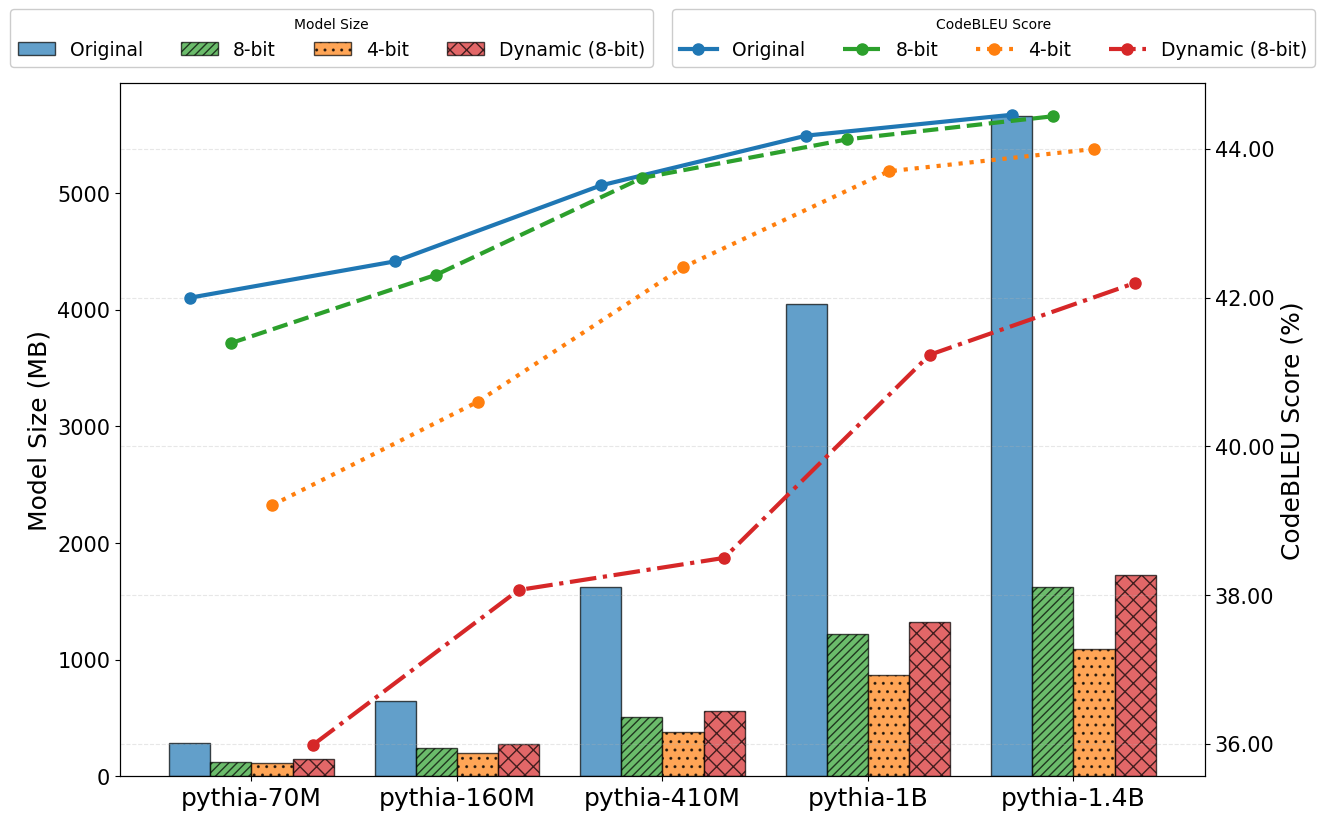

In [2]:
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=['Model', 'Compression', 'Size (MB)', 'BLEU']).iloc[:limit, :]

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()

# Define styles
bar_width = 0.2
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]  # Colorblind-friendly palette
patterns = ["", "////", "..", "xx"]  # Bar patterns
line_styles = ["-", "--", ":", "-."]  # Line styles
line_width = 3  # Thicker lines

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(14, 9))

# Plot bar chart for model sizes with patterns
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    bars = ax1.bar(
        x + i * bar_width, 
        subset["Size (MB)"], 
        width=bar_width, 
        label=f"{comp}", 
        color=colors[i],
        alpha=0.7,
        edgecolor='black',
        hatch=patterns[i]  # Add patterns
    )

ax1.set_ylabel("Model Size (MB)", fontsize=18)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, ha='center', fontsize=18)
ax1.legend(
    loc='upper left',
    bbox_to_anchor=(0-0.11, 1.12),
    title="Model Size",
    fontsize=13.5,
    ncol=len(compressions),
    framealpha=1  # Opaque background
)
ax1.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")
ax1.xaxis.set_tick_params(rotation=0, labelsize=18)

# Second y-axis for performance scores
ax2 = ax1.twinx()

# Plot line chart for performance with thicker lines
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(
        x + i * bar_width, 
        subset["BLEU"], 
        marker="o", 
        linestyle=line_styles[i],  # Unique line style
        linewidth=line_width,  # Thicker lines
        label=f"{comp}", 
        color=colors[i],
        markersize=8  # Larger markers
    )

ax2.set_ylabel("CodeBLEU Score (%)", fontsize=18)
ax2.legend(
    loc='upper right',
    bbox_to_anchor=(1.11, 1.12),
    title="CodeBLEU Score",
    ncol=len(compressions),
    fontsize=13.5,
    framealpha=1  # Opaque background
)
ax2.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")
# Add grid and formatting
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax1.yaxis.set_tick_params(rotation=0, labelsize=15)
ax2.yaxis.set_tick_params(labelsize=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.savefig("./output/model_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

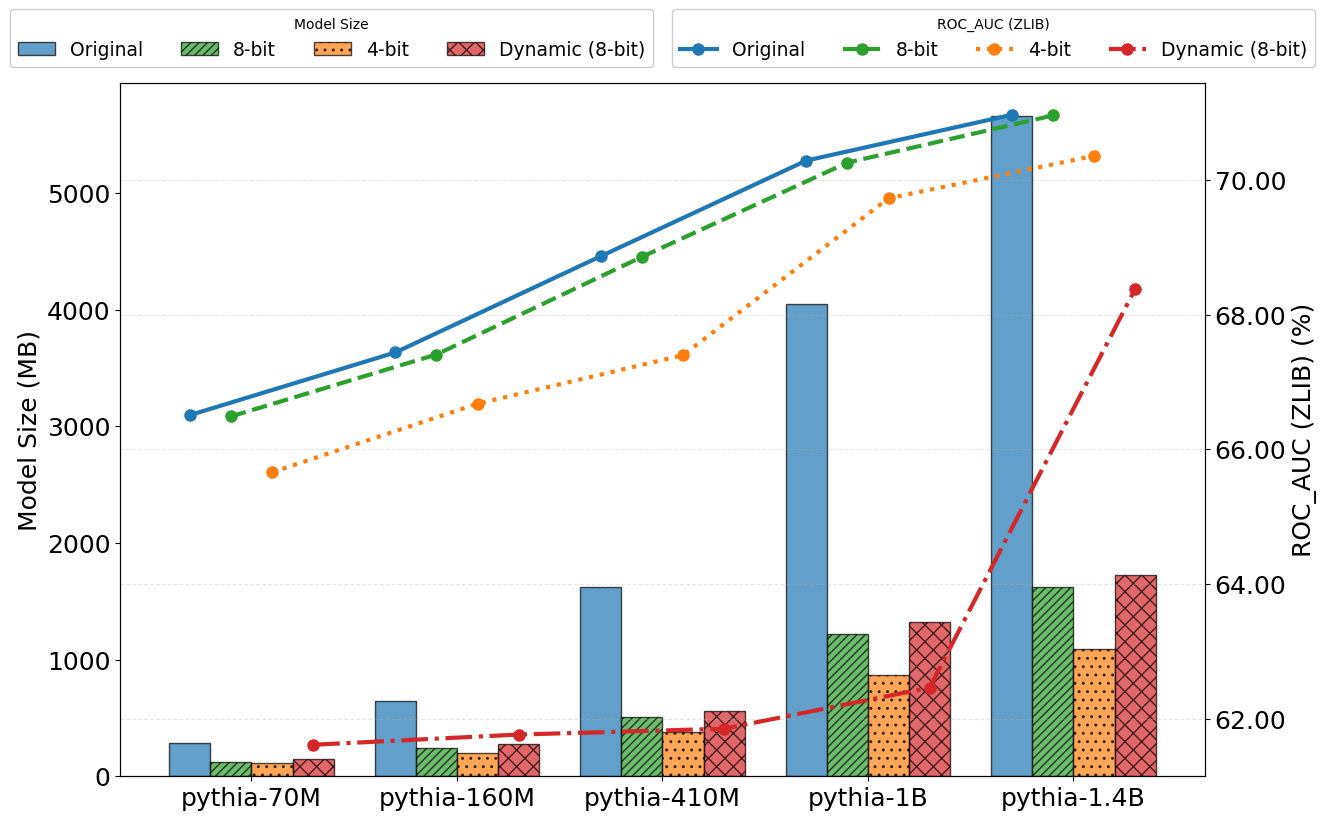

In [3]:
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=['Model', 'Compression', 'Size (MB)', 'ROC_AUC', 'PR_AUC', 'ROC_AUC.1', 'PR_AUC.1', 'ROC_AUC.2', 'PR_AUC.2', 'ROC_AUC.3', 'PR_AUC.3']).iloc[:limit, :]

def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # ==== 1. Define styles for clarity/accessibility ====
    bar_width = 0.2
    colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]  # Distinct colors
    patterns = ["", "////", "..", "xx"]  # Add patterns for bars
    line_styles = ["-", "--", ":", "-."]  # Distinct line styles
    line_width = 3  # Thicker lines

    x = np.arange(len(models))
    fig, ax1 = plt.subplots(figsize=(14, 9))

    # ==== 2. Improved Bar Chart (Model Sizes) ====
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        bars = ax1.bar(
            x + i * bar_width,
            subset["Size (MB)"],
            width=bar_width,
            label=f"{comp}",
            color=colors[i],
            alpha=0.7,
            edgecolor="black",  # Add edge for clarity
            hatch=patterns[i]  # Add patterns
        )

    ax1.set_ylabel("Model Size (MB)", fontsize=18)
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, ha='center', fontsize=18)
    ax1.legend(
        loc='upper left',
        bbox_to_anchor=(0-0.11, 1.12),
        title="Model Size",
        ncol=len(compressions),
        framealpha=1,  # Make legend background opaque
        fontsize=13.5  # Larger font for readability
    )
    ax1.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")

    # ==== 3. Improved Line Chart (Performance) ====
    ax2 = ax1.twinx()
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(
            x + i * bar_width,
            subset.iloc[:, 3],
            marker="o",
            linestyle=line_styles[i],  # Unique line style
            linewidth=line_width,  # Thicker lines
            label=f"{comp}",
            color=colors[i],
            markersize=8  # Larger markers
        )

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)", fontsize=18)
    ax2.legend(
        loc='upper right',
        bbox_to_anchor=(1.11, 1.12),
        title=f"{scoreName} ({miaName})",
        ncol=len(compressions),
        framealpha=1,
        fontsize=13.5  # Larger font for readability
    )
    ax2.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")
    ax1.xaxis.set_tick_params(rotation=0, labelsize=18)
    ax1.yaxis.set_tick_params(rotation=0, labelsize=18)
    ax2.yaxis.set_tick_params(labelsize=18)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    # ==== 4. Final Touches ====
    plt.grid(axis='y', linestyle='--', alpha=0.3)  # Add grid for readability
    plt.savefig(f"./output/{scoreName}({miaName}).pdf", dpi=300, bbox_inches="tight")
    plt.show()
genGraph(df.iloc[:, [0,1,2,7]], miaName="ZLIB")
# genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")